# Corruption + Metrics Visualization

Qualitative check of:
1. **Corruption effects** — what `corrupt_trend`, `corrupt_seasonal`, `corrupt_noise` actually do to a series
2. **Forecasts on clean vs corrupted** — model predictions before and after corruption
3. **Metric summary** — MASE, WQL, and scaled WQL across corruption types and both models

Models: `moiraie_base_7` (encoder) and `moiraic_base_11` (decoder), real pretrained weights.

In [1]:
import os, sys
sys.path.insert(0, os.getcwd())

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from einops import rearrange

from lib import generate_dataset, make_batch
from lib.synthetic import PERIOD_BINS
from lib.corruption import corrupt_trend, corrupt_seasonal, corrupt_noise, corrupt_add_noise
from lib.metrics import mase, weighted_quantile_loss, scaled_weighted_quantile_loss
from uni2ts.model.moiraie.module import MoiraieModule
from uni2ts.model.moiraic.module import MoiraicModule

plt.rcParams.update({'font.size': 8, 'axes.titlesize': 8})

In [2]:
# ── Constants ─────────────────────────────────────────────────────────────────
PATCH_SIZE      = 16
CONTEXT_PATCHES = 32
PRED_PATCHES    = 4
SERIES_LENGTH   = (CONTEXT_PATCHES + PRED_PATCHES) * PATCH_SIZE  # 576
CONTEXT_END     = CONTEXT_PATCHES * PATCH_SIZE                    # 512
N_PATCHES       = CONTEXT_PATCHES + PRED_PATCHES                  # 36
PRED_LENGTH     = PRED_PATCHES * PATCH_SIZE                       # 64
QUANTILE_LEVELS = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
MEDIAN_IDX      = 4  # index of q=0.5 in QUANTILE_LEVELS

MOIRAIE_PATH = '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last'
MOIRAIC_PATH = '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last'

In [3]:
# ── Load models ───────────────────────────────────────────────────────────────
module_e = MoiraieModule.from_pretrained(MOIRAIE_PATH).eval()
module_c = MoiraicModule.from_pretrained(MOIRAIC_PATH).eval()
print(f'moiraie  d_model={module_e.d_model}  layers={module_e.num_layers}  Q={module_e.num_quantiles}')
print(f'moiraic  d_model={module_c.d_model}  layers={module_c.num_layers}  Q={module_c.num_quantiles}  num_predict_token={module_c.num_predict_token}')

Loading weights from local directory
Loading weights from local directory
moiraie  d_model=512  layers=8  Q=9
moiraic  d_model=512  layers=8  Q=9  num_predict_token=4


In [4]:
# ── Synthetic dataset ─────────────────────────────────────────────────────────
data = generate_dataset(n=200, seed=42, patch_size=PATCH_SIZE,
                        context_patches=CONTEXT_PATCHES, pred_patches=PRED_PATCHES)
print('series:', data['series'].shape)
print('period_idx distribution:', dict(zip(*np.unique(data['period_idx'], return_counts=True))))

series: (200, 576)
period_idx distribution: {0: 28, 1: 27, 2: 21, 3: 21, 4: 24, 5: 20, 6: 29, 7: 30}


In [5]:
# ── Helper: run one model on a single 1D series, return [Q, pred_length] ─────
@torch.no_grad()
def forecast_e(series_1d):
    """moiraie: predictions at token indices [32:36]."""
    batch = make_batch(series_1d[None], PATCH_SIZE, CONTEXT_PATCHES, PRED_PATCHES)
    raw = module_e(**batch, training_mode=False)   # [1, 36, Q*P]
    pred = raw[:, CONTEXT_PATCHES:, :]              # [1, 4, Q*P]
    return rearrange(pred, '1 seq (q p) -> q (seq p)',
                     q=module_e.num_quantiles, p=PATCH_SIZE).numpy()

@torch.no_grad()
def forecast_c(series_1d):
    """moiraic: predictions at last context token [31]."""
    batch = make_batch(series_1d[None], PATCH_SIZE, CONTEXT_PATCHES, PRED_PATCHES)
    raw = module_c(**batch, training_mode=False, past_cache=None, return_cache=False)  # [1, 36, T*Q*P]
    last = raw[:, CONTEXT_PATCHES - 1, :]           # [1, T*Q*P]
    return rearrange(last, '1 (t q p) -> q (t p)',
                     t=PRED_PATCHES, q=module_c.num_quantiles, p=PATCH_SIZE).numpy()

print('forecast_e shape:', forecast_e(data['series'][0]).shape)
print('forecast_c shape:', forecast_c(data['series'][0]).shape)

forecast_e shape: (9, 64)
forecast_c shape: (9, 64)


In [6]:
# ── Helper: build all four versions of a series for a given example index ────
def make_versions(i):
    s   = data['series'][i]
    slope    = float(data['slope'][i])
    p_idx    = int(data['period_idx'][i])
    phase    = float(np.arctan2(data['phase_sin'][i], data['phase_cos'][i]))
    seed     = i * 7919
    return {
        'clean':    s,
        'no_trend': corrupt_trend(s, slope),
        'no_seasonal': corrupt_seasonal(s, p_idx, phase),
        'noise':    corrupt_add_noise(s, seed),
    }

CORRUPTION_LABELS = {
    'clean':       ('Clean',            'steelblue'),
    'no_trend':    ('Corrupt: no trend','darkorange'),
    'no_seasonal': ('Corrupt: no seasonal','seagreen'),
    'noise':       ('Corrupt: noise',   'firebrick'),
}

---
## 1  Corruption Visualization

Each column is one synthetic example.  
Row 1 = clean series; rows 2–4 = the three corruptions.  
Blue shading = context (512 steps); red shading = prediction horizon (64 steps).

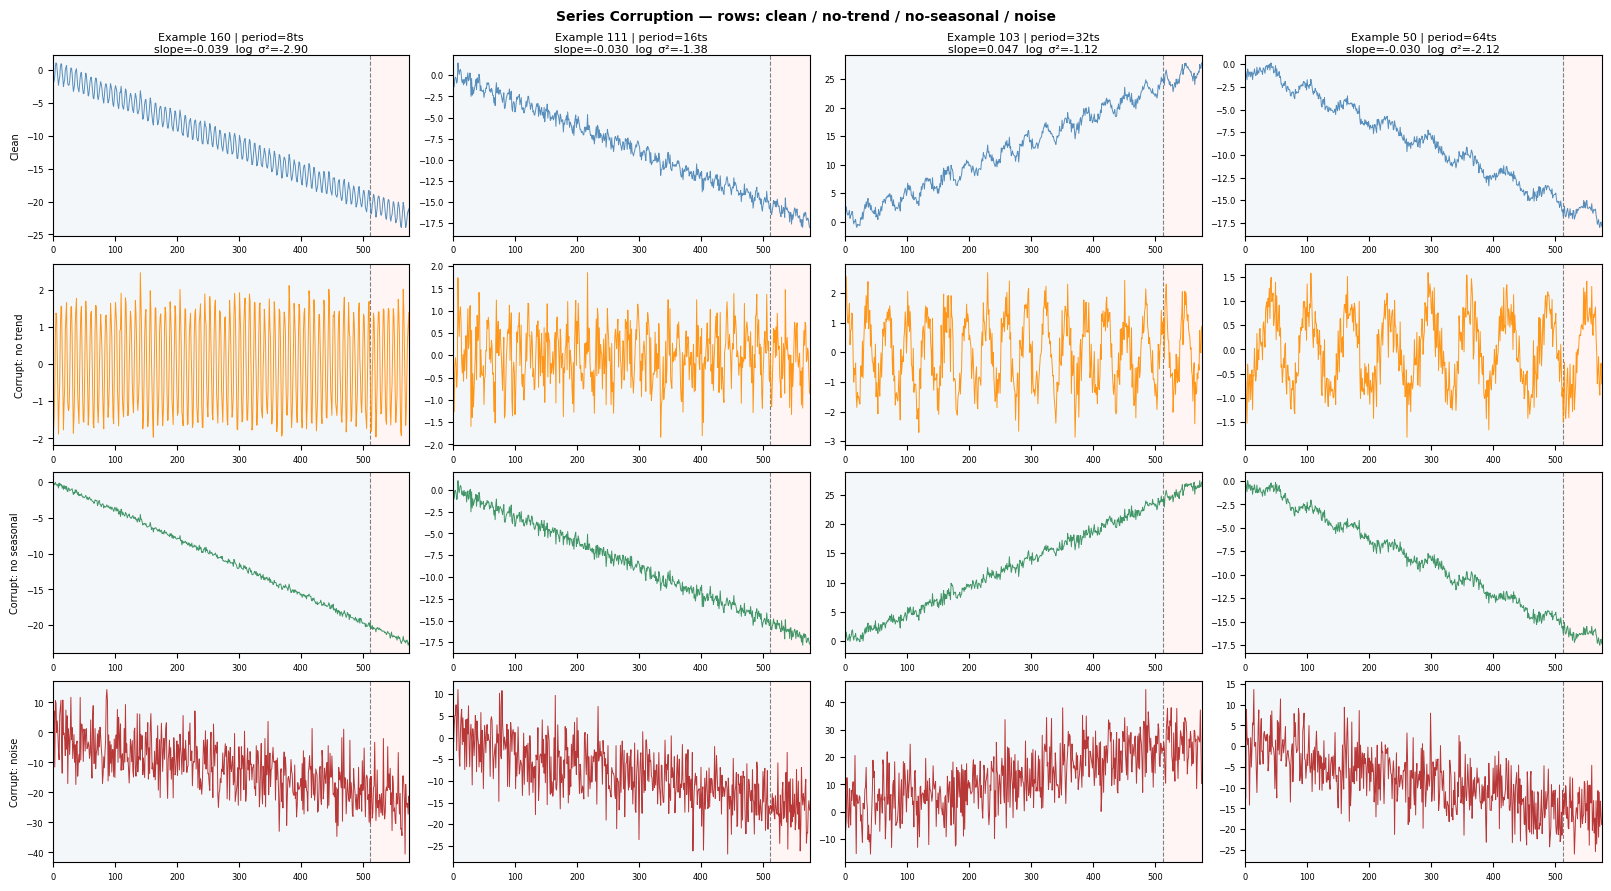

In [7]:
# Pick one example per period class (4 distinct periods visible in first 4 bins)
SHOW_IDXS = []
rng = np.random.default_rng(0)
for pidx in [4, 5, 6, 7]:   # 8, 16, 32, 64 time-step periods
    candidates = np.where(data['period_idx'] == pidx)[0]
    SHOW_IDXS.append(int(rng.choice(candidates)))

t = np.arange(SERIES_LENGTH)
corruption_keys = list(CORRUPTION_LABELS.keys())

fig, axes = plt.subplots(4, 4, figsize=(4 * 4.0, 4 * 2.2), constrained_layout=True)
fig.suptitle('Series Corruption — rows: clean / no-trend / no-seasonal / noise', fontsize=10, fontweight='bold')

for col, i in enumerate(SHOW_IDXS):
    versions = make_versions(i)
    period_ts = PERIOD_BINS[int(data['period_idx'][i])]
    for row, key in enumerate(corruption_keys):
        ax = axes[row, col]
        label, color = CORRUPTION_LABELS[key]
        s = versions[key]
        ax.axvspan(0, CONTEXT_END, alpha=0.06, color='steelblue', lw=0)
        ax.axvspan(CONTEXT_END, SERIES_LENGTH, alpha=0.06, color='tomato', lw=0)
        ax.axvline(CONTEXT_END, color='gray', lw=0.8, ls='--')
        ax.plot(t, s, lw=0.7, color=color, alpha=0.9)
        if row == 0:
            ax.set_title(f'Example {i} | period={period_ts}ts\nslope={data["slope"][i]:.3f}  log_σ²={data["log_noise_var"][i]:.2f}', pad=2)
        if col == 0:
            ax.set_ylabel(label, fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xlim(0, SERIES_LENGTH - 1)

plt.show()

---
## 2  Forecast: Clean vs Corrupted

For each example, both models (moiraie = encoder, moiraic = decoder) produce quantile forecasts on the clean series and on each corruption.  
Shaded band = 10th–90th percentile interval.  Solid line = median (q=0.5).  Dotted orange = ground-truth target.

In [8]:
def plot_forecast_panel(ax, series_1d, qpreds, target, title, color='steelblue'):
    """Plot context + quantile forecast on ax.
    qpreds: [Q, PRED_LENGTH];  target: [PRED_LENGTH].
    """
    ctx = series_1d[:CONTEXT_END]
    t_ctx  = np.arange(CONTEXT_END)
    t_pred = np.arange(CONTEXT_END, SERIES_LENGTH)

    ax.axvspan(0, CONTEXT_END, alpha=0.05, color='steelblue', lw=0)
    ax.axvspan(CONTEXT_END, SERIES_LENGTH, alpha=0.05, color='tomato', lw=0)
    ax.axvline(CONTEXT_END, color='gray', lw=0.8, ls='--')

    ax.plot(t_ctx, ctx, lw=0.7, color='gray', alpha=0.8)
    ax.fill_between(t_pred, qpreds[0], qpreds[-1], alpha=0.2, color=color)
    ax.fill_between(t_pred, qpreds[2], qpreds[-3], alpha=0.3, color=color)
    ax.plot(t_pred, qpreds[MEDIAN_IDX], lw=1.2, color=color, label='median')
    ax.plot(t_pred, target, lw=0.9, color='darkorange', ls=':', label='target')

    ax.set_title(title, pad=2)
    ax.set_xlim(0, SERIES_LENGTH - 1)
    ax.tick_params(labelsize=6)

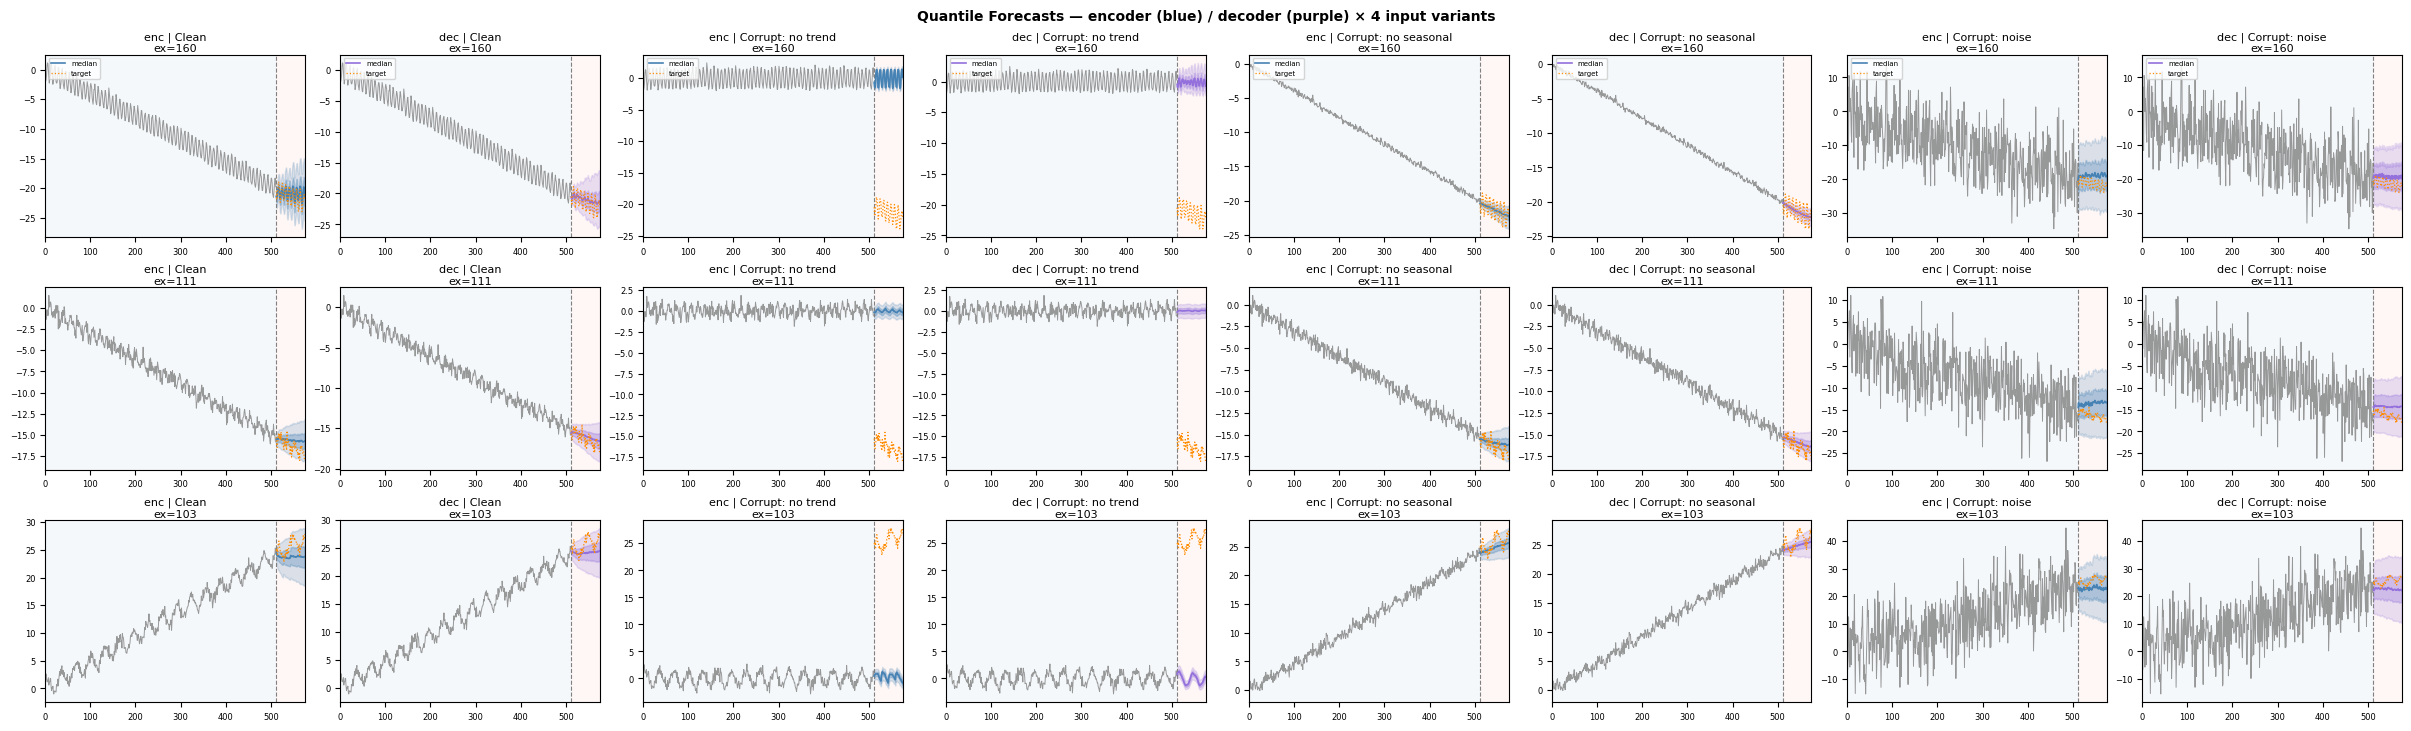

In [9]:
N_EXAMPLES = 3   # change to show more examples
SHOW_EXAMPLES = SHOW_IDXS[:N_EXAMPLES]

# rows: one per example; cols: 4 versions × 2 models = 8 columns
n_rows = N_EXAMPLES
n_cols = len(corruption_keys) * 2   # 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.0, n_rows * 2.4),
                         constrained_layout=True)
fig.suptitle('Quantile Forecasts — encoder (blue) / decoder (purple) × 4 input variants',
             fontsize=10, fontweight='bold')

for row, i in enumerate(SHOW_EXAMPLES):
    versions = make_versions(i)
    target   = data['series'][i][CONTEXT_END:]

    for k, key in enumerate(corruption_keys):
        s = versions[key]
        qe = forecast_e(s)   # [Q, 64]
        qc = forecast_c(s)   # [Q, 64]

        label, _ = CORRUPTION_LABELS[key]

        ax_e = axes[row, k * 2]     if n_rows > 1 else axes[k * 2]
        ax_c = axes[row, k * 2 + 1] if n_rows > 1 else axes[k * 2 + 1]

        plot_forecast_panel(ax_e, s, qe, target,
                            f'enc | {label}\nex={i}', color='steelblue')
        plot_forecast_panel(ax_c, s, qc, target,
                            f'dec | {label}\nex={i}', color='mediumpurple')

        if row == 0:
            for ax in (ax_e, ax_c):
                ax.legend(fontsize=5, loc='upper left')

plt.show()

---
## 3  Metric Summary — first 50 examples

For each corruption × model combination, compute MASE, WQL, and SWQL over the first 50 examples, then visualize as grouped bar charts.

**MASE** uses the median forecast; **WQL** / **SWQL** use all 9 quantile levels.

In [10]:
N_EVAL = 50
results = {model: {key: {'mase': [], 'wql': [], 'swql': []}
                   for key in corruption_keys}
           for model in ('encoder', 'decoder')}

for i in range(N_EVAL):
    versions = make_versions(i)
    target   = data['series'][i][CONTEXT_END:]
    context  = data['series'][i][:CONTEXT_END]

    for key in corruption_keys:
        s  = versions[key]
        qe = forecast_e(s)  # [Q, 64]
        qc = forecast_c(s)  # [Q, 64]

        for (model_label, qpreds) in [('encoder', qe), ('decoder', qc)]:
            median_fc = qpreds[MEDIAN_IDX]
            results[model_label][key]['mase'].append(mase(median_fc, target, context))
            results[model_label][key]['wql'].append(
                weighted_quantile_loss(qpreds, QUANTILE_LEVELS, target))
            results[model_label][key]['swql'].append(
                scaled_weighted_quantile_loss(qpreds, QUANTILE_LEVELS, target, context))

print('Done.')

Done.


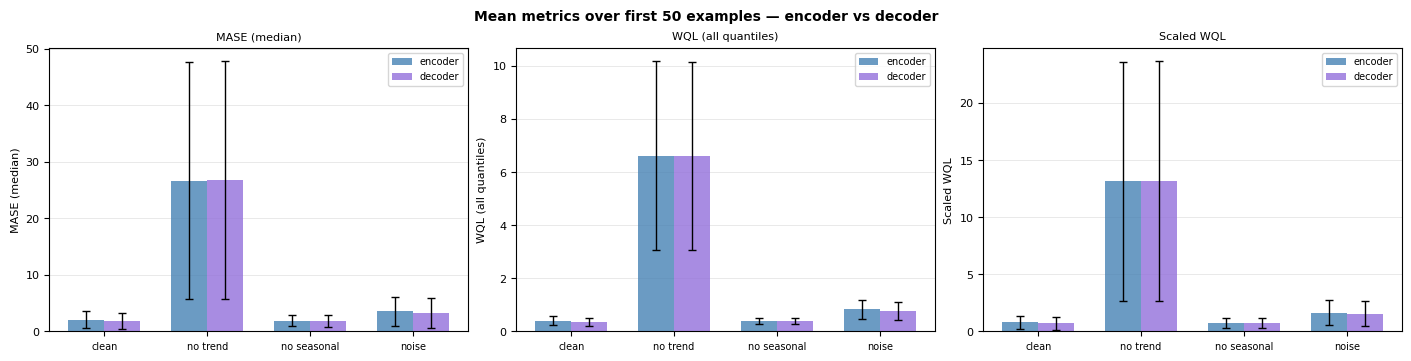

In [11]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
metric_keys   = ['mase', 'wql', 'swql']
metric_labels = ['MASE (median)', 'WQL (all quantiles)', 'Scaled WQL']
model_colors  = {'encoder': 'steelblue', 'decoder': 'mediumpurple'}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
fig.suptitle(f'Mean metrics over first {N_EVAL} examples — encoder vs decoder', fontsize=10, fontweight='bold')

x      = np.arange(len(corruption_keys))
width  = 0.35
x_tick_labels = [CORRUPTION_LABELS[k][0].replace('Corrupt: ', '').replace('Clean', 'clean') for k in corruption_keys]

for ax, mk, ml in zip(axes, metric_keys, metric_labels):
    for offset, model in zip([-width/2, width/2], ('encoder', 'decoder')):
        means = [np.mean(results[model][k][mk]) for k in corruption_keys]
        stds  = [np.std(results[model][k][mk])  for k in corruption_keys]
        bars  = ax.bar(x + offset, means, width, yerr=stds,
                       label=model, color=model_colors[model],
                       alpha=0.8, error_kw={'elinewidth': 1, 'capsize': 3})

    ax.set_title(ml)
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, fontsize=7)
    ax.set_ylabel(ml)
    ax.legend(fontsize=7)
    ax.yaxis.grid(True, lw=0.4, alpha=0.5)
    ax.set_axisbelow(True)

plt.show()

---
## 4  Per-example MASE: clean vs each corruption

Scatter plot: x = MASE on clean series, y = MASE on corrupted series.  
Points above the diagonal = corruption degraded performance.  
One panel per corruption type; encoder (blue) vs decoder (purple).

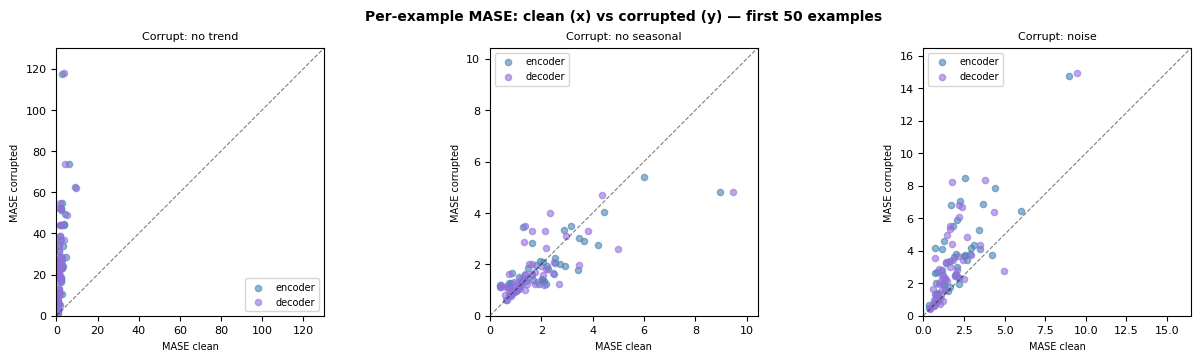

In [12]:
corruption_only = [k for k in corruption_keys if k != 'clean']

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
fig.suptitle(f'Per-example MASE: clean (x) vs corrupted (y) — first {N_EVAL} examples',
             fontsize=10, fontweight='bold')

for ax, key in zip(axes, corruption_only):
    label, _ = CORRUPTION_LABELS[key]
    for model, color in model_colors.items():
        clean_mase = results[model]['clean']['mase']
        corr_mase  = results[model][key]['mase']
        ax.scatter(clean_mase, corr_mase, s=20, alpha=0.6, color=color, label=model)

    lim = max(ax.get_xlim()[1], ax.get_ylim()[1]) * 1.05
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlabel('MASE clean', fontsize=7)
    ax.set_ylabel('MASE corrupted', fontsize=7)
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.set_aspect('equal')

plt.show()

---
## 5  Metric degradation ratio

`ratio = metric(corrupted) / metric(clean)`.  Values > 1 mean corruption worsened the forecast.  
Helps see which corruption type hurts each model more — and whether encoder vs decoder responds differently.

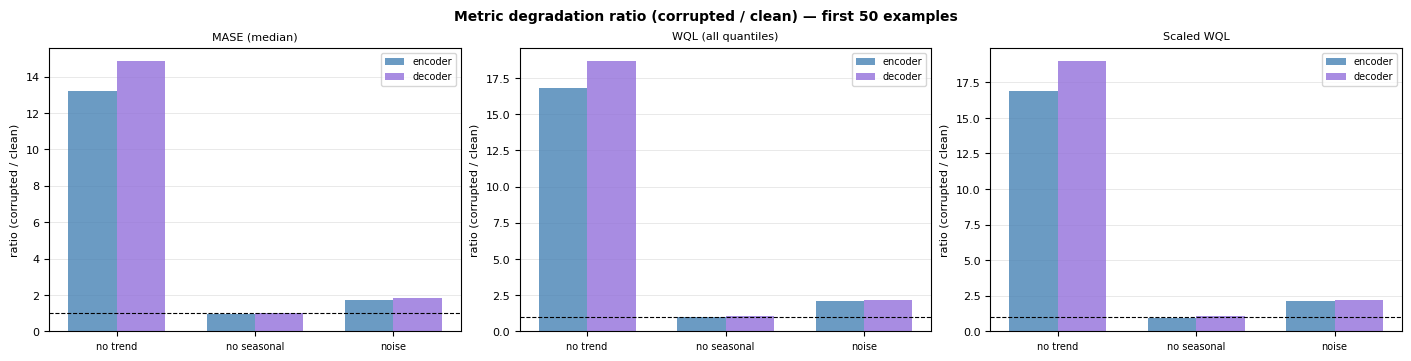

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
fig.suptitle(f'Metric degradation ratio (corrupted / clean) — first {N_EVAL} examples',
             fontsize=10, fontweight='bold')

for ax, mk, ml in zip(axes, metric_keys, metric_labels):
    ratios_e, ratios_c = [], []
    for key in corruption_only:
        clean_e = np.mean(results['encoder']['clean'][mk])
        clean_c = np.mean(results['decoder']['clean'][mk])
        ratios_e.append(np.mean(results['encoder'][key][mk]) / (clean_e + 1e-8))
        ratios_c.append(np.mean(results['decoder'][key][mk]) / (clean_c + 1e-8))

    x_labels = [CORRUPTION_LABELS[k][0].replace('Corrupt: ', '') for k in corruption_only]
    xp = np.arange(len(corruption_only))
    ax.bar(xp - width/2, ratios_e, width, label='encoder', color='steelblue', alpha=0.8)
    ax.bar(xp + width/2, ratios_c, width, label='decoder', color='mediumpurple', alpha=0.8)
    ax.axhline(1.0, color='black', lw=0.8, ls='--')
    ax.set_xticks(xp)
    ax.set_xticklabels(x_labels, fontsize=7)
    ax.set_title(ml)
    ax.set_ylabel('ratio (corrupted / clean)')
    ax.legend(fontsize=7)
    ax.yaxis.grid(True, lw=0.4, alpha=0.5)
    ax.set_axisbelow(True)

plt.show()

---
## 6  Side-by-side forecast detail for one example

A single example shown in full across all four input variants and both models — useful for a close-up qualitative check of the quantile bands.

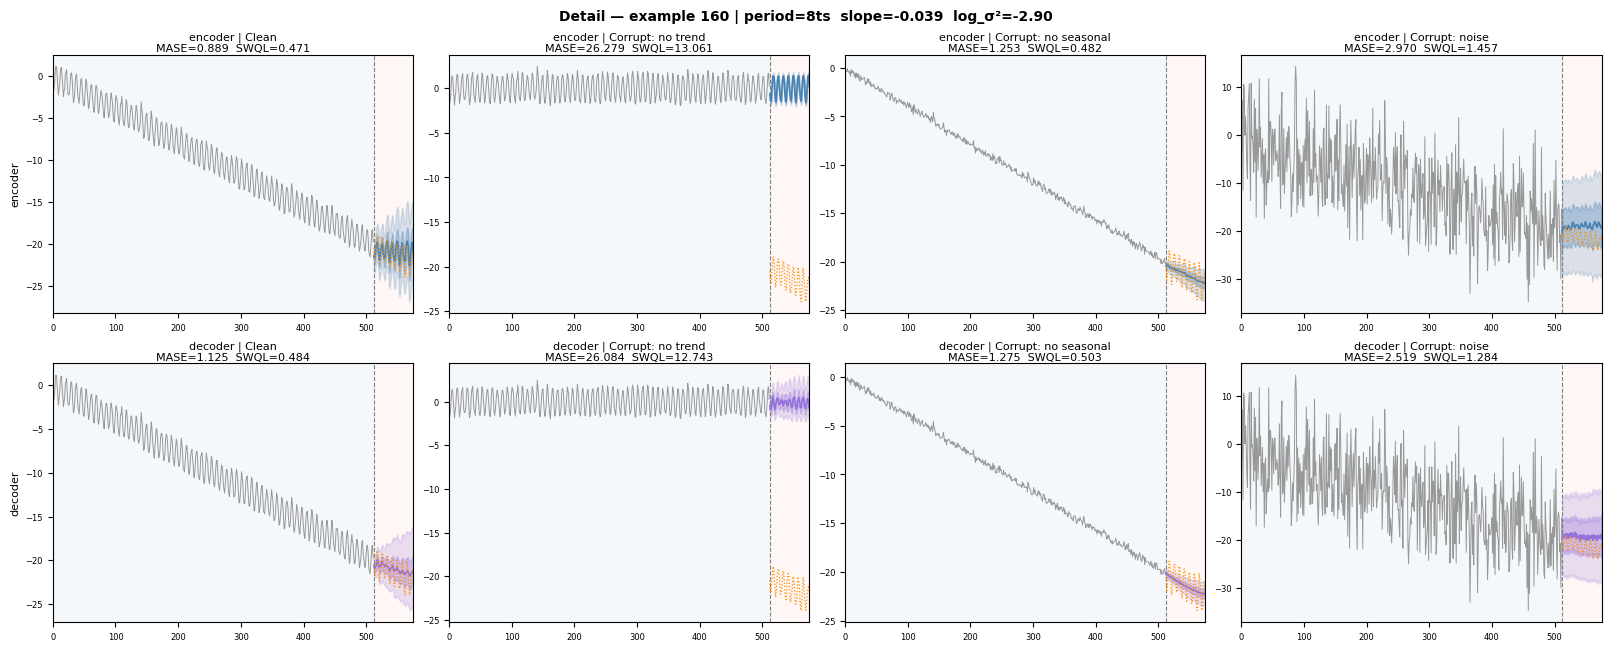

In [14]:
DETAIL_IDX = SHOW_IDXS[0]   # change to any example index

versions = make_versions(DETAIL_IDX)
target   = data['series'][DETAIL_IDX][CONTEXT_END:]
context  = data['series'][DETAIL_IDX][:CONTEXT_END]

fig, axes = plt.subplots(2, 4, figsize=(4 * 4.0, 2 * 3.2), constrained_layout=True)
fig.suptitle(
    f'Detail — example {DETAIL_IDX} | period={PERIOD_BINS[int(data["period_idx"][DETAIL_IDX])]}ts  '
    f'slope={data["slope"][DETAIL_IDX]:.3f}  log_σ²={data["log_noise_var"][DETAIL_IDX]:.2f}',
    fontsize=10, fontweight='bold')

for col, key in enumerate(corruption_keys):
    s    = versions[key]
    qe   = forecast_e(s)
    qc   = forecast_c(s)
    label, _ = CORRUPTION_LABELS[key]

    mase_e  = mase(qe[MEDIAN_IDX], target, context)
    mase_c  = mase(qc[MEDIAN_IDX], target, context)
    swql_e  = scaled_weighted_quantile_loss(qe, QUANTILE_LEVELS, target, context)
    swql_c  = scaled_weighted_quantile_loss(qc, QUANTILE_LEVELS, target, context)

    plot_forecast_panel(axes[0, col], s, qe, target,
                        f'encoder | {label}\nMASE={mase_e:.3f}  SWQL={swql_e:.3f}',
                        color='steelblue')
    plot_forecast_panel(axes[1, col], s, qc, target,
                        f'decoder | {label}\nMASE={mase_c:.3f}  SWQL={swql_c:.3f}',
                        color='mediumpurple')

axes[0, 0].set_ylabel('encoder', fontsize=8)
axes[1, 0].set_ylabel('decoder', fontsize=8)

plt.show()